# Example: Transcriptional Dynamics

The following applies minibatch and adaptive minibatch SMC ABC to the problem of estimating parameters from a transcriptional dynamics snapshot model of smFISH (single-molecule Fluorescent in situ Hybridization). The heterogeneity in these models is given by the shape (length L in this case) and transcription start site (z). The model is of bursty expression, following:


Will be filled out later

In [1]:
## Import smc abc class and schemes
from smc_abc import smc_abc_iterator as abc_iter
import smc_abc_schemes as schemes
import smc_abc_utils as utils
import numpy as np

from matplotlib import pyplot as plt

#A class that generates smfish transcriptional dynamics snapshots
import transcriptional_dynamics as td

cwd appended to system path


## Constant Minibatch SMC ABC

In [2]:
#### Model parameters 
seed = 0
sample_size = 512
kplus = 30
kminus = 10
rburst = 10
diffusivity = 0.1

true_params = np.array([kplus,rburst,diffusivity])
num_params = true_params.shape[0]


T,dt = 5,0.01
bp,gp = 2,4
lengths = np.random.gamma(shape = gp, scale = 1/gp, size = (sample_size,))
sites = np.random.beta(a = bp,b = bp, size = (sample_size,)) * lengths

# homogeneous
#lengths = np.ones(shape = (sample_size,))
#sites = 0.5*lengths

length_index = np.arange(sample_size)
print(np.var(lengths), np.var(sites))


data_ = td.simulate(kplus, kminus, rburst, diffusivity, T, dt, sites, lengths)
data = np.array([np.asarray(d) for d in data_],dtype=object)


def model(p,i):
    z = sites[i,]
    l = lengths[i,]
    obs_data = data[i]
    sim = np.array(td.simulate(p[0], kminus, p[1], p[2], T, dt, z, l),dtype = object)
    return sim, obs_data


#### Estimation parameters
## General
alpha = 0.5
num_particles = 500
num_sims = 5
cores = 4

## Prior
prior = utils.uniform_prior([[1,100],[1,100],[0,1.0]])

def stats_func0(x):
    counts = np.array([u.shape[0] for u in x], dtype=float)
    mean_counts = np.mean(counts)
    var_influence = (counts - mean_counts)**2
    rmsd = np.array([np.std(u) if u.size >=2 else 0 for u in x], dtype=float)
    stats = np.vstack((counts, var_influence, rmsd)).T
    return stats

def stats_func(x,y,sf = stats_func0):
    return sf(x),sf(y)


## Distance function
dist_func = 'mahalanobis'


######## This makes a dictionary of information shared with the adaptive minibatch schemes
init_params = {
    'data':data,
    'model':model,
    'stats_func':stats_func,
    'prior':prior,
    'dist_func':dist_func,
    'num_particles':num_particles,
    'cores':cores,
    'alpha':alpha,
    'seed':seed
}

0.26245207222662154 0.12804143352099104


Running benchmarks...
Batch 1: 0.000049 sec
Batch 2: 0.000097 sec
Batch 4: 0.000187 sec
Batch 8: 0.000365 sec
Batch 16: 0.000726 sec
Batch 32: 0.001442 sec
Batch 64: 0.002925 sec
Batch 128: 0.006459 sec
Batch 256: 0.012981 sec
Batch 512: 0.025990 sec
Average increase in seconds per sample: 4.787913105448954e-05


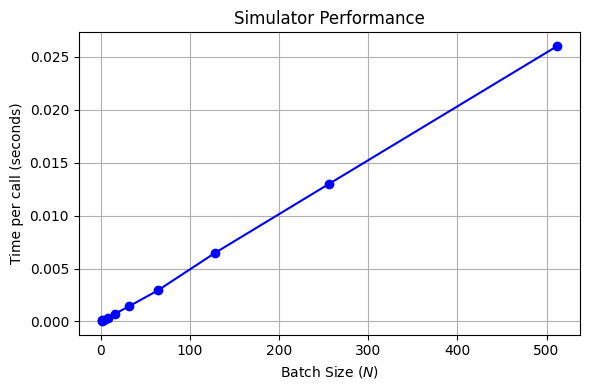

In [4]:
utils.benchmark_time([1,2,4,8,16,32,64,128,256,512],lambda n: td.simulate(kplus, kminus, rburst, diffusivity, T, dt, sites[:n], lengths[:n]))

In [5]:
est = schemes.constant_init(init_params,[32])

while est.snr > 2.0:
    schemes.constant_loop(est)

Generation: 1. Batch Size: 32. Acceptance Rate: 1.000. Step time: 9.508. Total time 9.508. post-filter threshold: 15.4504. ESS: 500.00. Log HDPR vol: 8.764
Estimated v_total = 162.226. Noise: v/n = 5.070. Noise floor estimate: v/N = 0.317. Estimated c = 0.141. SNR: eps^2 / (v/n) = 47.088. Time per sim: 0.010
Generation: 2. Batch Size: 32. Acceptance Rate: 0.669. Step time: 3.957. Total time 13.465. post-filter threshold: 3.6867. ESS: 472.83. Log HDPR vol: 8.588
Estimated v_total = 19.154. Noise: v/n = 0.599. Noise floor estimate: v/N = 0.037. Estimated c = 0.203. SNR: eps^2 / (v/n) = 22.707. Time per sim: 0.003
Generation: 3. Batch Size: 32. Acceptance Rate: 0.514. Step time: 3.829. Total time 17.294. post-filter threshold: 1.7496. ESS: 431.04. Log HDPR vol: 8.422
Estimated v_total = 10.304. Noise: v/n = 0.322. Noise floor estimate: v/N = 0.020. Estimated c = 0.314. SNR: eps^2 / (v/n) = 9.506. Time per sim: 0.002
Generation: 4. Batch Size: 32. Acceptance Rate: 0.315. Step time: 4.923. 

In [7]:
est = schemes.constant_init(init_params,[512])

while est.snr > 2.0:
    schemes.constant_loop(est)

Generation: 1. Batch Size: 512. Acceptance Rate: 1.000. Step time: 71.676. Total time 71.676. post-filter threshold: 16.2337. ESS: 500.00. Log HDPR vol: 8.702
Estimated v_total = 262.952. Noise: v/n = 0.514. Noise floor estimate: v/N = 0.514. Estimated c = 0.000. SNR: eps^2 / (v/n) = 513.134. Time per sim: 0.072
Generation: 2. Batch Size: 512. Acceptance Rate: 0.712. Step time: 62.847. Total time 134.523. post-filter threshold: 3.5553. ESS: 468.44. Log HDPR vol: 8.568
Estimated v_total = 30.202. Noise: v/n = 0.059. Noise floor estimate: v/N = 0.059. Estimated c = 0.000. SNR: eps^2 / (v/n) = 214.287. Time per sim: 0.045
Generation: 3. Batch Size: 512. Acceptance Rate: 0.513. Step time: 64.376. Total time 198.899. post-filter threshold: 1.6977. ESS: 475.89. Log HDPR vol: 8.045
Estimated v_total = 11.408. Noise: v/n = 0.022. Noise floor estimate: v/N = 0.022. Estimated c = 0.000. SNR: eps^2 / (v/n) = 129.360. Time per sim: 0.033
Generation: 4. Batch Size: 512. Acceptance Rate: 0.419. Step

In [6]:
est = schemes.fvc_init(init_params,[2,None,1.0])

while est.snr > 2.0:
    schemes.fvc_loop(est)

Generation: 1. Batch Size: 2. Acceptance Rate: 1.000. Step time: 0.555. Total time 0.555. post-filter threshold: 6.3433. ESS: 500.00. Log HDPR vol: 8.787
Estimated v_total = 6.043. Noise: v/n = 3.021. Noise floor estimate: v/N = 0.012. Estimated c = 0.273. SNR: eps^2 / (v/n) = 13.318. Time per sim: 0.001
Automatic c selection: c = 0.2734830067785398
New hyperparameter set: [2, np.float64(0.2734830067785398), 1.0]
Estimated v_total with ema: 6.043. Batch size update: 2
Generation: 2. Batch Size: 2. Acceptance Rate: 0.617. Step time: 0.799. Total time 1.354. post-filter threshold: 2.3772. ESS: 466.19. Log HDPR vol: 8.781
Estimated v_total = 4.606. Noise: v/n = 2.303. Noise floor estimate: v/N = 0.009. Estimated c = 0.637. SNR: eps^2 / (v/n) = 2.454. Time per sim: 0.000
Estimated v_total with ema: 4.606. Batch size update: 11
Generation: 3. Batch Size: 11. Acceptance Rate: 0.354. Step time: 2.638. Total time 3.992. post-filter threshold: 1.4844. ESS: 470.41. Log HDPR vol: 8.639
Estimated 